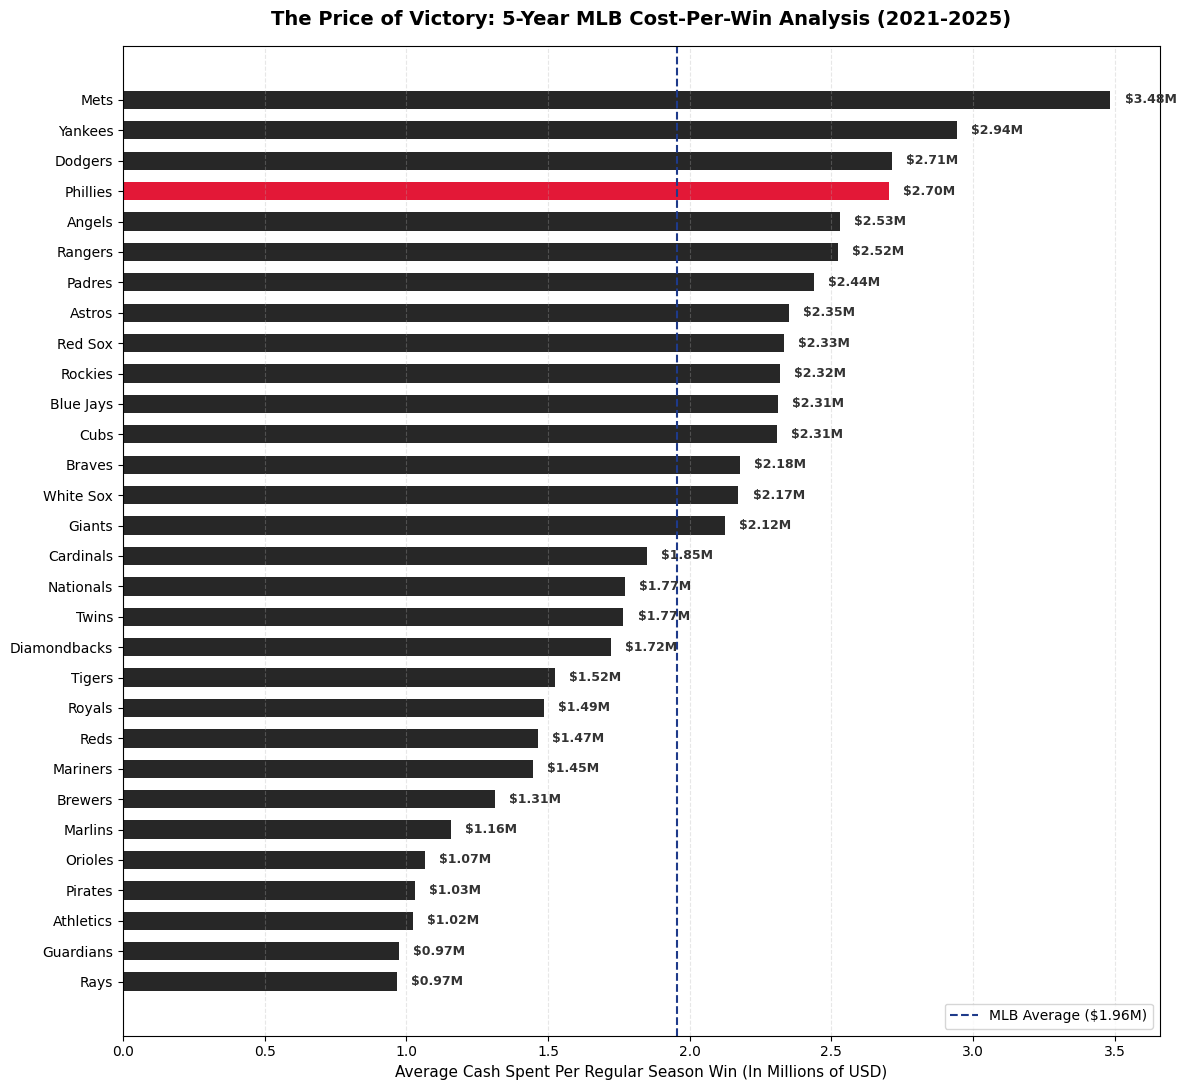

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

#1 Load in Data from Spreadsheet
df = pd.read_csv("mlb_5year_efficiency.csv", header=1)

df.columns = df.columns.str.strip()
df['Team'] = df['Team'].astype(str).str.strip()

df['Adjusted_Payroll'] = pd.to_numeric(df['Adjusted_Payroll'], errors='coerce')
df['Wins'] = pd.to_numeric(df['Wins'], errors='coerce')

#2 Combine 5 seasons together to find long-term totals
grouped = df.groupby('Team').sum().reset_index()

#3 Calculate Cost per Win Index
grouped['Cost_Per_Win'] = grouped['Adjusted_Payroll'] / grouped['Wins']

# Sort the league from most expensive to most efficient front office
ranked_mlb = grouped.sort_values(by='Cost_Per_Win', ascending=False)

#4 Create Visualization Model
plt.figure(figsize=(12, 11))

#Highlight Phillies in Red and all other teams in Dark Gray
colors = ['#E31837' if t == 'Phillies' else '#272727' for t in ranked_mlb['Team']]

#Convert Unit to Millions
bars = plt.barh(ranked_mlb['Team'], ranked_mlb['Cost_Per_Win'] / 1000000, color=colors, height=0.6)

#Calculate and Draw MLB Average Spending Line
mlb_avg_cost = (grouped['Adjusted_Payroll'].sum() / grouped['Wins'].sum()) / 1000000
plt.axvline(mlb_avg_cost, color='#1E3A8A', linewidth=1.5, linestyle='--', label=f'MLB Average (${mlb_avg_cost:.2f}M)')

#Customized Layout
plt.title("The Price of Victory: 5-Year MLB Cost-Per-Win Analysis (2021-2025)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Average Cash Spent Per Regular Season Win (In Millions of USD)", fontsize=11)
plt.gca().invert_yaxis()  # Most expensive teams at the top
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.legend(loc='lower right')

# Precise Value annotations next to each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.05, bar.get_y() + bar.get_height()/2, f"${width:.2f}M",
             va='center', ha='left', fontsize=9, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig("mlb_5year_cost_per_win.png", dpi=300)
plt.show()